# Association Rule Learning on the Groceries Dataset
**Carlos HARERIMANA** - Student ID: 101200

MSDA 9213 - Data Mining | Master of Science in Big Data Analytics | Adventist University of Central Africa

Code repository: https://github.com/charerimana/data-mining-labs/blob/master/groceries_association_rules.ipynb

In this notebook I use association rule learning to find products that customers in the Groceries
dataset tend to buy together. I work with three measures throughout:
- **Support** - how often an itemset appears across all baskets.
- **Confidence** - how reliable a rule is, i.e. P(consequent | antecedent).
- **Lift** - how much stronger the association is than pure chance.

I use the Apriori algorithm from the `mlxtend` library.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 60)

# report figures are saved as <FIG_PREFIX>_<what the graph shows>.png
FIG_PREFIX = 'groceries_association_rules'

### Load the data
Each line in `groceries.csv` is one shopping trip. The lines have a variable number of items and are
padded with empty fields, so I read them line by line and drop the blanks.

In [2]:
DATA_PATH = "data/groceries.csv"

transactions = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        items = [x.strip() for x in line.strip().split(",") if x.strip() != ""]
        if items:
            transactions.append(items)

print(f"Number of transactions loaded: {len(transactions)}")
print("Example basket:", transactions[0])

Number of transactions loaded: 9835
Example basket: ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']


In [3]:
# turn the baskets into a one-hot table (rows = transactions, columns = items)
te = TransactionEncoder()
basket = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)
basket.iloc[:5, :6]

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False


## Question 1 - Understand the Data
Here I report the number of transactions, the number of distinct items, and the 10 most frequent items.

In [4]:
n_transactions = len(transactions)
n_items = basket.shape[1]
print("a) Transactions :", n_transactions)
print("b) Distinct items:", n_items)

item_counts  = basket.sum().sort_values(ascending=False)
item_support = item_counts / n_transactions

top10 = pd.DataFrame({
    "item": item_counts.index[:10],
    "count": item_counts.values[:10],
    "support": item_support.values[:10].round(4),
})
print("\nc) Top 10 most frequently purchased items:")
top10

a) Transactions : 9835
b) Distinct items: 169

c) Top 10 most frequently purchased items:


,item,count,support
0,whole milk,2513,0.2555
1,other vegetables,1903,0.1935
2,rolls/buns,1809,0.1839
3,soda,1715,0.1744
4,yogurt,1372,0.1395
5,bottled water,1087,0.1105
6,root vegetables,1072,0.1090
7,tropical fruit,1032,0.1049
8,shopping bags,969,0.0985
9,sausage,924,0.0940


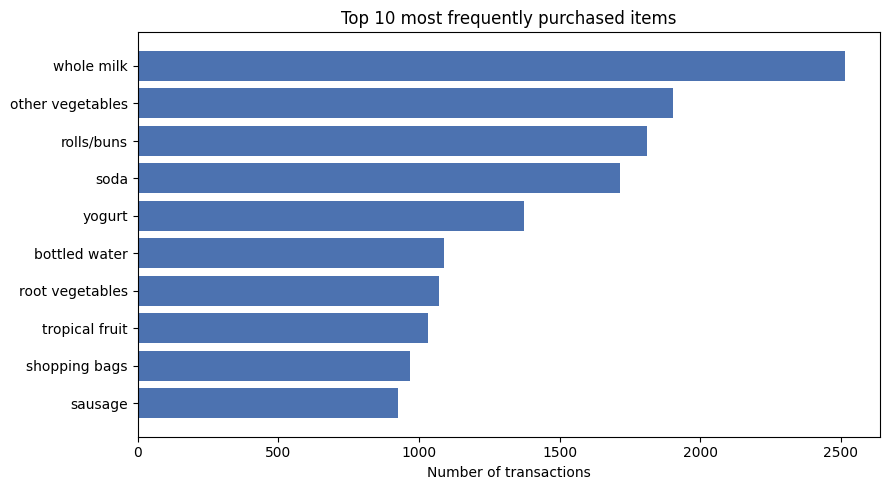

In [5]:
plt.figure(figsize=(9, 5))
plt.barh(top10["item"][::-1], top10["count"][::-1], color="#4C72B0")
plt.xlabel("Number of transactions")
plt.title("Top 10 most frequently purchased items")
plt.tight_layout()
plt.savefig(f"{FIG_PREFIX}_top_items.png", dpi=150)
plt.show()

**My answers - Q1**
- **a)** 9,835 transactions.
- **b)** 169 distinct items.
- **c)** whole milk, other vegetables, rolls/buns, soda, yogurt, bottled water, root vegetables, tropical fruit, shopping bags, sausage.

Whole milk alone appears in about 26% of baskets, but even the top item is in only around 1 in 4 trips,
so the baskets are very varied.

## Question 2 - Frequent Itemsets
I look for itemsets of two or more products that occur together often, with their support. I run Apriori
with `min_support = 0.01`, so an itemset must appear in at least 1% of baskets to be kept.

In [6]:
frequent = apriori(basket, min_support=0.01, use_colnames=True)
frequent["length"] = frequent["itemsets"].apply(len)

multi = (frequent[frequent["length"] >= 2]
         .sort_values("support", ascending=False)
         .reset_index(drop=True))
multi["itemset"] = multi["itemsets"].apply(lambda s: ", ".join(sorted(s)))

print(f"Frequent itemsets with 2+ items: {len(multi)}")
top_itemsets = multi[["itemset", "length", "support"]].head(10).copy()
top_itemsets["support"] = top_itemsets["support"].round(4)
top_itemsets

Frequent itemsets with 2+ items: 245


,itemset,length,support
0,"other vegetables, whole milk",2,0.0748
1,"rolls/buns, whole milk",2,0.0566
2,"whole milk, yogurt",2,0.0560
3,"root vegetables, whole milk",2,0.0489
4,"other vegetables, root vegetables",2,0.0474
5,"other vegetables, yogurt",2,0.0434
6,"other vegetables, rolls/buns",2,0.0426
7,"tropical fruit, whole milk",2,0.0423
8,"soda, whole milk",2,0.0401
9,"rolls/buns, soda",2,0.0383


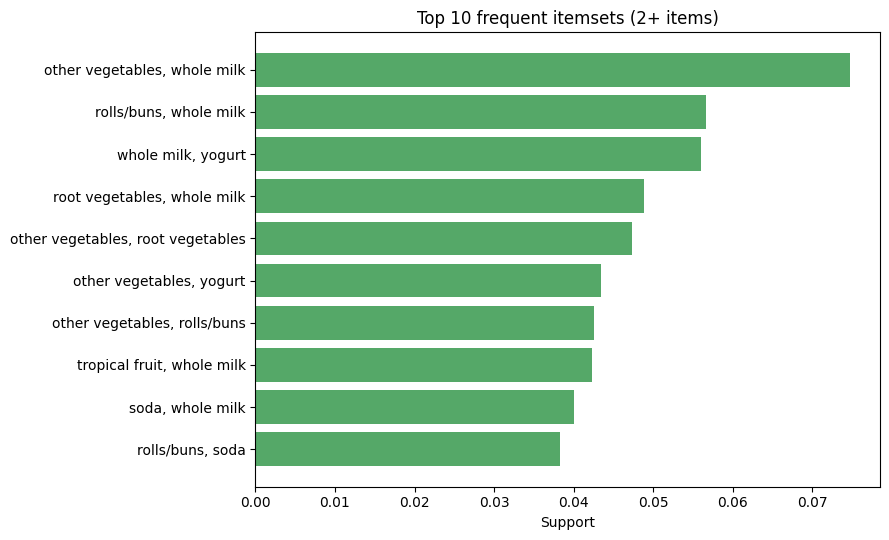

In [7]:
plt.figure(figsize=(9, 5.5))
plt.barh(top_itemsets["itemset"][::-1], top_itemsets["support"][::-1], color="#55A868")
plt.xlabel("Support")
plt.title("Top 10 frequent itemsets (2+ items)")
plt.tight_layout()
plt.savefig(f"{FIG_PREFIX}_frequent_itemsets.png", dpi=150)
plt.show()

In [8]:
best = top_itemsets.iloc[0]
print("c) Highest-support itemset:", best["itemset"], "=", best["support"])

c) Highest-support itemset: other vegetables, whole milk = 0.0748


**My answers - Q2**
- **a) / b)** The 10 highest-support pairs are listed above with their support values.
- **c)** Highest support: **{other vegetables, whole milk} = 0.0748**.
- **d)** Support tells me how popular a combination is across all customers. A support of 0.0748 means
  about 7-8 of every 100 shopping trips contain both items. High-support itemsets are the everyday
  staple combinations the store sees most often.

## Question 3 - Association Rules
I generate rules from the frequent itemsets with a minimum confidence of 0.25, and report the
antecedent, consequent, support, confidence and lift for each.

In [9]:
rules = association_rules(frequent, metric="confidence", min_threshold=0.25)
rules["antecedent"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules["consequent"] = rules["consequents"].apply(lambda s: ", ".join(sorted(s)))

rules_disp = (rules[["antecedent", "consequent", "support", "confidence", "lift"]]
              .sort_values("lift", ascending=False)
              .reset_index(drop=True))
rules_disp[["support", "confidence", "lift"]] = rules_disp[["support", "confidence", "lift"]].round(4)

print(f"Total rules generated: {len(rules_disp)}")
rules_disp.head(12)

Total rules generated: 170


,antecedent,consequent,support,confidence,lift
0,"citrus fruit, other vegetables",root vegetables,0.0104,0.3592,3.2950
1,"other vegetables, tropical fruit",root vegetables,0.0123,0.3428,3.1448
2,beef,root vegetables,0.0174,0.3314,3.0404
3,"citrus fruit, root vegetables",other vegetables,0.0104,0.5862,3.0296
4,"root vegetables, tropical fruit",other vegetables,0.0123,0.5845,3.0210
5,"other vegetables, whole milk",root vegetables,0.0232,0.3098,2.8421
6,"curd, whole milk",yogurt,0.0101,0.3852,2.7614
7,"other vegetables, yogurt",root vegetables,0.0129,0.2974,2.7287
8,"other vegetables, yogurt",tropical fruit,0.0123,0.2834,2.7005
9,"other vegetables, rolls/buns",root vegetables,0.0122,0.2864,2.6275


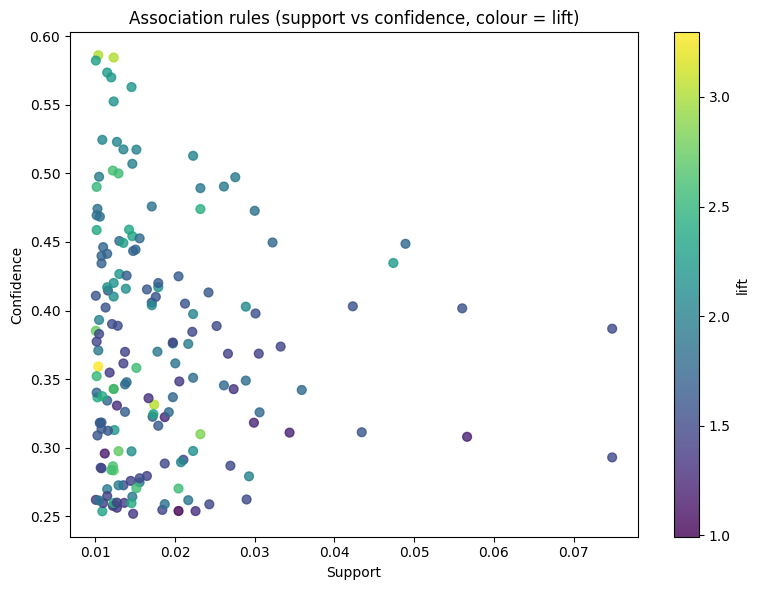

In [10]:
# save the full rule table for the report appendix
rules_disp.to_csv("q3_association_rules.csv", index=False)

plt.figure(figsize=(8, 6))
sc = plt.scatter(rules["support"], rules["confidence"], c=rules["lift"], cmap="viridis", s=40, alpha=0.8)
plt.colorbar(sc, label="lift")
plt.xlabel("Support"); plt.ylabel("Confidence")
plt.title("Association rules (support vs confidence, colour = lift)")
plt.tight_layout()
plt.savefig(f"{FIG_PREFIX}_support_vs_confidence.png", dpi=150)
plt.show()

## Question 4 - Understanding the Measures
I picked three rules and pulled their exact numbers below.

In [11]:
def show(ante, cons):
    row = rules_disp[(rules_disp.antecedent == ante) & (rules_disp.consequent == cons)].iloc[0]
    print(f"{{{ante}}} -> {{{cons}}}")
    print(f"   support={row.support}  confidence={row.confidence}  lift={row.lift}\n")

show("other vegetables, whole milk", "root vegetables")
show("citrus fruit, root vegetables", "other vegetables")
show("curd, whole milk", "yogurt")

{other vegetables, whole milk} -> {root vegetables}
   support=0.0232  confidence=0.3098  lift=2.8421

{citrus fruit, root vegetables} -> {other vegetables}
   support=0.0104  confidence=0.5862  lift=3.0296

{curd, whole milk} -> {yogurt}
   support=0.0101  confidence=0.3852  lift=2.7614



**Rule A: {other vegetables, whole milk} -> {root vegetables}** (supp 0.0232, conf 0.310, lift 2.842)
- **Support:** about 2.3% of all baskets contain all three items together.
- **Confidence:** 31% of customers who bought other vegetables and whole milk also bought root vegetables.
- **Lift:** those customers are about 2.8x more likely to buy root vegetables than a random customer - a strong positive association.

**Rule B: {citrus fruit, root vegetables} -> {other vegetables}** (supp 0.0104, conf 0.586, lift 3.030)
- **Support:** about 1% of baskets contain all three together.
- **Confidence:** when a basket has citrus fruit and root vegetables, 58.6% of the time it also has other vegetables - very reliable.
- **Lift:** about 3x more likely than average.

**Rule C: {curd, whole milk} -> {yogurt}** (supp 0.0101, conf 0.385, lift 2.761)
- **Support:** about 1% of baskets contain all three together.
- **Confidence:** 38.5% of curd + whole milk buyers also buy yogurt.
- **Lift:** about 2.8x more likely than chance - an intuitive dairy-with-dairy pattern.

## Question 5 - Find Interesting Rules
I take the rule with the highest confidence, the highest lift, and the highest support.

In [12]:
by_conf = rules_disp.sort_values("confidence", ascending=False).iloc[0]
by_lift = rules_disp.sort_values("lift", ascending=False).iloc[0]
by_supp = rules_disp.sort_values("support", ascending=False).iloc[0]

pd.DataFrame({
    "criterion":  ["Highest confidence", "Highest lift", "Highest support"],
    "antecedent": [by_conf.antecedent, by_lift.antecedent, by_supp.antecedent],
    "consequent": [by_conf.consequent, by_lift.consequent, by_supp.consequent],
    "support":    [by_conf.support, by_lift.support, by_supp.support],
    "confidence": [by_conf.confidence, by_lift.confidence, by_supp.confidence],
    "lift":       [by_conf.lift, by_lift.lift, by_supp.lift],
})

,criterion,antecedent,consequent,support,confidence,lift
0,Highest confidence,"citrus fruit, root vegetables",other vegetables,0.0104,0.5862,3.0296
1,Highest lift,"citrus fruit, other vegetables",root vegetables,0.0104,0.3592,3.2950
2,Highest support,whole milk,other vegetables,0.0748,0.2929,1.5136


**My answers - Q5**
- **a) Highest confidence:** {citrus fruit, root vegetables} -> {other vegetables} (0.586).
- **b) Highest lift:** {citrus fruit, other vegetables} -> {root vegetables} (3.295).
- **c) Highest support:** {whole milk} -> {other vegetables} (0.0748).
- **d) Same rule?** **No.** Each measure rewards something different. Support favours the best-selling
  products (whole milk, other vegetables) even when the lift is modest (1.51). Confidence and lift favour
  the fruit-and-vegetable combinations, which are rarer overall but very strongly linked when they occur.
  A good rule scores reasonably on all three, not just one.

## Question 6 - Interpret a Rule
**My chosen rule:** {root vegetables, tropical fruit} -> {other vegetables} (support 0.0123, confidence 0.585, lift 3.021).

In [13]:
show("root vegetables, tropical fruit", "other vegetables")

{root vegetables, tropical fruit} -> {other vegetables}
   support=0.0123  confidence=0.5845  lift=3.021



**In plain language:** customers who buy root vegetables and tropical fruit together also tend to buy
other vegetables on the same trip.

**Strong or weak?** I read this as a **strong** association. The confidence is 0.585 (almost 6 in 10 such
customers add other vegetables), and the lift of 3.02 (well above 1) means it is about three times more
likely than if the purchases were unrelated. It also makes sense to me - these are all fresh-produce
items, so a produce shopper buys across the section. Its only limitation is the modest support
(~1.2% of baskets).

## Question 7 - Business Application (Supermarket Manager)
**a) Two products to place close together:** other vegetables and whole milk - the most frequent pair
(support 0.0748), so putting them near each other serves the many customers who buy both.

**b) A possible product bundle:** a "Fresh Produce" bundle of root vegetables + tropical fruit +
other vegetables, based on the strong rule in Q6 (confidence 0.585, lift 3.02), e.g. a small discount on
the third item.

**c) Recommending products:** when a basket already contains curd and whole milk, I would recommend
yogurt (Rule C, lift 2.76) at checkout or in the app, since those customers are about 2.8x more likely
to want it. This is the same idea behind "customers who bought this also bought..." and targeted receipt
coupons.

## Question 8 - Understanding Association
**a) Does a rule prove causation?** No. Rules only show that items are bought together more often than
expected, not that one *causes* the other. A third factor (a meal plan, a promotion, shelf placement) or
mere co-occurrence of popular items can explain the link. Association is correlation, not cause.

**b) High confidence but low lift?** Confidence can be high just because the consequent is very popular
on its own. Many rules point to whole milk with decent confidence only because whole milk is in about 25%
of baskets. Since lift divides confidence by that baseline support, a very popular consequent pushes lift
toward 1 - the rule adds little real information despite good confidence.

**c) Lift > 1?** It means the two sides appear together more often than expected under independence - a
positive association; the higher the lift, the stronger the link. (Lift = 1 means independence; lift < 1
means a negative association.)

## Appendix - Notes and Reference
**Saved figures.** Running this notebook writes the three report figures to the working folder:
- `groceries_association_rules_top_items.png`
- `groceries_association_rules_frequent_itemsets.png`
- `groceries_association_rules_support_vs_confidence.png`

**Settings.** Apriori with minimum support 0.01; rules kept at minimum confidence 0.25. The full rule
table is saved to `q3_association_rules.csv`.

**Code repository:** https://github.com/charerimana/data-mining-labs/blob/master/groceries_association_rules.ipynb